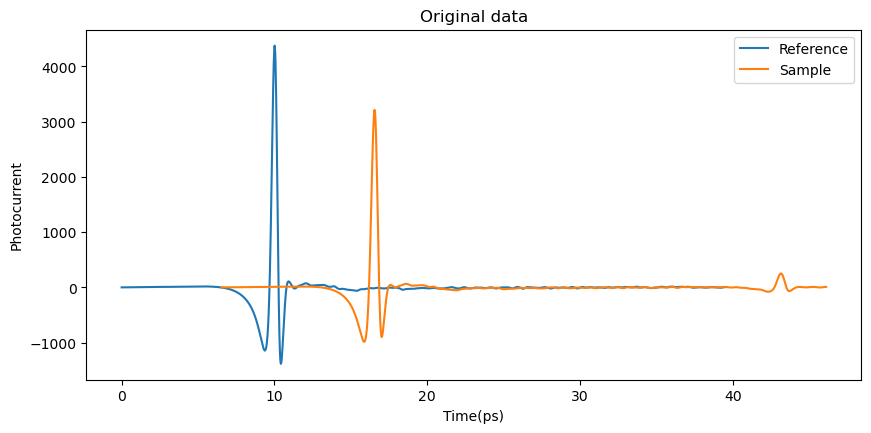

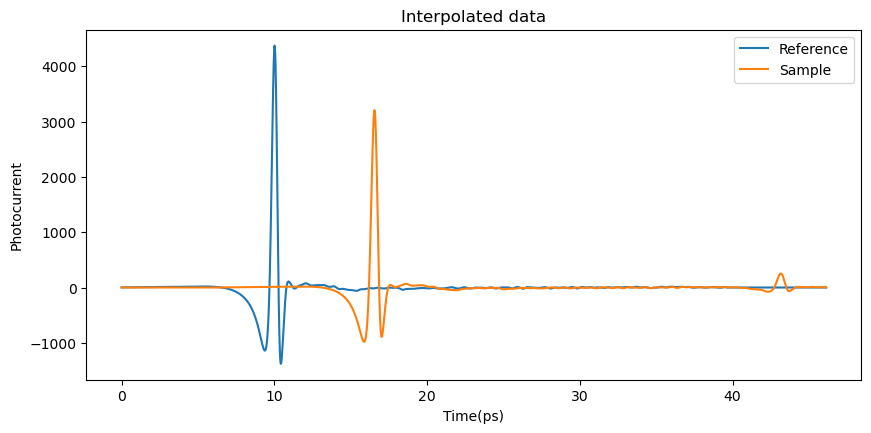

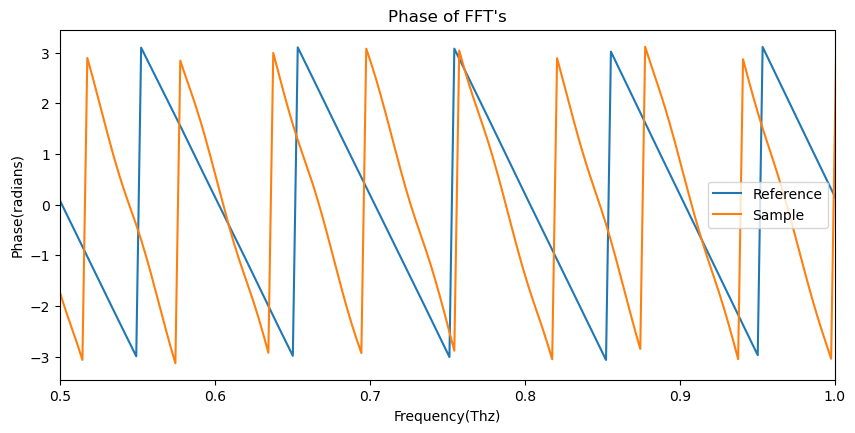

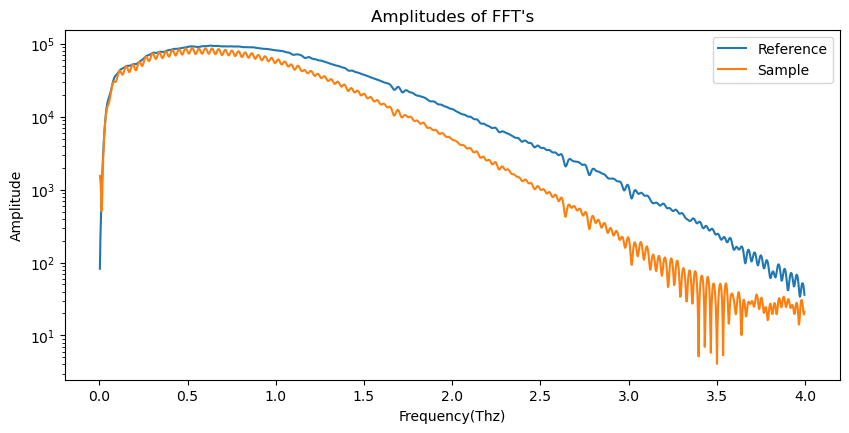

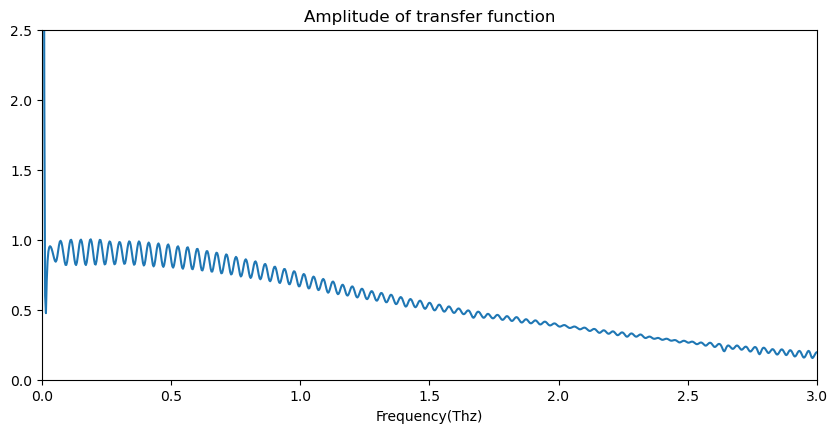

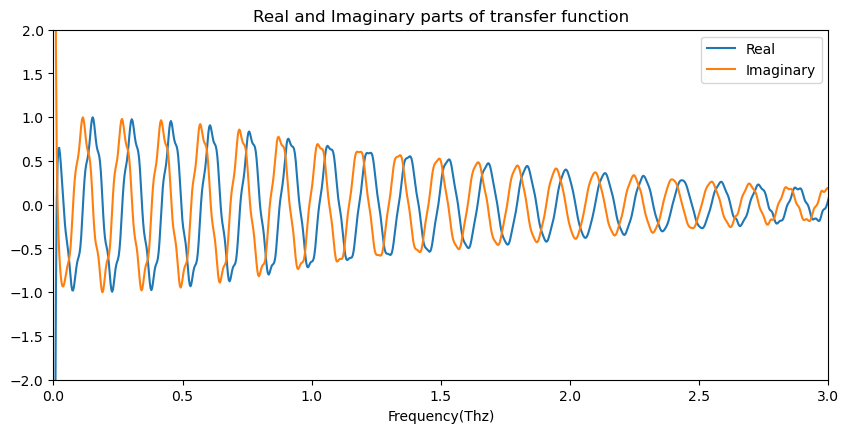

In [5]:
import numpy as np 
import matplotlib.pyplot as plt 

# LOAD DATA
datar=np.loadtxt("2mmR.dat",delimiter=",")
datas=np.loadtxt("2mmS.dat",delimiter=",")
ts=datas[:,0]
tr=datar[:,0]
sr=datar[:,1]
ss=datas[:,1]

# PLOT ORIGINAL DATA
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(tr*10**12,sr,label="Reference")
plt.plot(ts*10**12,ss,label="Sample")
plt.title("Original data")
plt.xlabel("Time(ps)")
plt.ylabel("Photocurrent")
plt.legend()
plt.show()

# INTERPOLATION
startt=0
endt=4.6116*10**-11
dt=min(np.mean(np.diff(ts)),np.mean(np.diff(tr)))
t = np.arange(startt, endt + dt, dt)

sr=np.interp(t,tr,sr,left=0,right=0)
ss=np.interp(t,ts,ss,left=0,right=0)


# PLOT INTERPOLATED DATA WITH ZERO PADDING
plt.figure(figsize=(10,10))     
plt.subplot(2,1,2)
plt.plot(t*10**12,sr,label="Reference")
plt.plot(t*10**12,ss,label="Sample")
plt.xlabel("Time(ps)")
plt.ylabel("Photocurrent")
plt.title("Interpolated data")
plt.legend()
plt.show()

# FFT
#16384
fftr=np.fft.fft(sr,16384)
ffts=np.fft.fft(ss,16384)
freq=np.fft.fftfreq(16384,dt)

# MASK
mask=(freq>0)&(freq<4*10**12)
# MASKED FFT
fftr=fftr[mask]
ffts=ffts[mask]
freq=freq[mask]

#PLOT PHASE VS FREQ
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(freq*10**-12,np.angle(fftr),label="Reference")
plt.plot(freq*10**-12,np.angle(ffts),label="Sample")
plt.xlabel("Frequency(Thz)")
plt.ylabel("Phase(radians)")
plt.xlim(0.5,1)
plt.title("Phase of FFT's")
plt.legend()
plt.show()

#PLOT AMPLITUDE VS FREQ
plt.figure(figsize=(10,10))
plt.subplot(2,1,2)
plt.semilogy(freq*10**-12,np.abs(fftr),label="Reference")
plt.semilogy(freq*10**-12,np.abs(ffts),label="Sample")
plt.xlabel("Frequency(Thz)")
plt.ylabel("Amplitude")
plt.title("Amplitudes of FFT's")
plt.legend()
plt.show()

#TRANSFER FUNCTION 
tf=ffts/fftr

#PLOT AMPLITUDE OF TRANSFER VS FREQUENCY
plt.figure(figsize=(10,10))
plt.subplot(2,1,1)
plt.plot(freq*10**-12,np.abs(tf))
plt.title("Amplitude of transfer function")
plt.xlabel("Frequency(Thz)")
plt.xlim(0,3)
plt.ylim(0,2.5)
plt.show()

#PLOT IMAGINARY AND REAL PART OF TRANSFER VS FREQ
plt.figure(figsize=(10,10))
plt.subplot(2,1,2)
plt.plot(freq*10**-12,np.real(tf),label="Real")
plt.plot(freq*10**-12,np.imag(tf),label="Imaginary")
plt.title("Real and Imaginary parts of transfer function")
plt.xlabel("Frequency(Thz)")
plt.xlim(0,3)
plt.ylim(-2,2)
plt.legend()
plt.show()

